Name: Chinmay Ghule
MIS: 112415054
Assignment 2

## Q1

In [24]:
import numpy as np

A = np.array([[12,  5,  8, 20],
              [ 7, 15,  3, 11],
              [25,  9, 18,  6],
              [10, 14,  2, 16]])

def binarize_by_row_mean(arr):
    """Return a binary matrix: 1 where an element exceeds its own row mean, else 0."""
    row_means = arr.mean(axis=1, keepdims=True)
    return (arr > row_means).astype(int)

binary = binarize_by_row_mean(A)

counts = binary.sum(axis=1)
best = np.flatnonzero(counts == counts.max())

print("Binary matrix:\n", binary)
print("\nCount above row mean:", counts)
print("Row with the most elements above their mean:", best)

Binary matrix:
 [[1 0 0 1]
 [0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]]

Count above row mean: [2 2 2 2]
Row with the most elements above their mean: [0 1 2 3]


## Q2

In [25]:
X = np.array([[10,100,5],[12,110,6],[11,105,7],[13,500,6],[14,108,8],[15,115,9]])
print(X.shape)

mu  = X.mean(axis=0)
sd  = X.std(axis=0)
med = np.median(X, axis=0)
print(mu, mu.shape)

mask = np.abs(X - mu) > 2 * sd
print(mask)

X_clean = np.where(mask, med, X)

print(X_clean)
print(X)

(6, 3)
[ 12.5        173.           6.83333333] (3,)
[[False False False]
 [False False False]
 [False False False]
 [False  True False]
 [False False False]
 [False False False]]
[[ 10. 100.   5.]
 [ 12. 110.   6.]
 [ 11. 105.   7.]
 [ 13. 109.   6.]
 [ 14. 108.   8.]
 [ 15. 115.   9.]]
[[ 10 100   5]
 [ 12 110   6]
 [ 11 105   7]
 [ 13 500   6]
 [ 14 108   8]
 [ 15 115   9]]


## Q3

In [26]:
import pandas as pd

df = pd.DataFrame({
    'Student': ['A','B','C','D','E','F','G','H'],
    'Department': ['CSE','CSE','ECE','ECE','CSE','ECE','CSE','ECE'],
    'Gender': ['F','M','F','M','M','F','F','M'],
    'Marks': [85,72,91,65,78,88,95,70],
    'Attendance': [92,81,96,72,85,90,98,75]})

print(df)

  Student Department Gender  Marks  Attendance
0       A        CSE      F     85          92
1       B        CSE      M     72          81
2       C        ECE      F     91          96
3       D        ECE      M     65          72
4       E        CSE      M     78          85
5       F        ECE      F     88          90
6       G        CSE      F     95          98
7       H        ECE      M     70          75


In [27]:
# Part 1:
dept_avg_marks = df.groupby('Department')['Marks'].mean()
print("1. Average marks by department:\n", dept_avg_marks, "\n")

# Part 2:
dept_gender_avg = df.groupby(['Department', 'Gender'])['Marks'].mean()
print("2. Average marks by department and gender:\n", dept_gender_avg, "\n")

# Part 3:
toppers = df.loc[df.groupby('Department')['Marks'].idxmax()]
print("3. Highest scorer per department:\n", toppers, "\n")

# Part 4:
dept_mean_per_row = df.groupby('Department')['Marks'].transform('mean')
above_avg = df[df['Marks'] > dept_mean_per_row]
print("4. Students above their department average:\n", above_avg, "\n")

# Part 5:
dept_attendance = df.groupby('Department')['Attendance'].mean()
print("5. Average attendance:\n", dept_attendance)
print("   Highest:", dept_attendance.idxmax())

1. Average marks by department:
 Department
CSE    82.5
ECE    78.5
Name: Marks, dtype: float64 

2. Average marks by department and gender:
 Department  Gender
CSE         F         90.0
            M         75.0
ECE         F         89.5
            M         67.5
Name: Marks, dtype: float64 

3. Highest scorer per department:
   Student Department Gender  Marks  Attendance
6       G        CSE      F     95          98
2       C        ECE      F     91          96 

4. Students above their department average:
   Student Department Gender  Marks  Attendance
0       A        CSE      F     85          92
2       C        ECE      F     91          96
5       F        ECE      F     88          90
6       G        CSE      F     95          98 

5. Average attendance:
 Department
CSE    89.00
ECE    83.25
Name: Attendance, dtype: float64
   Highest: CSE


## Q4

In [28]:
df = pd.DataFrame({
    'ID':    [101,102,103,101,104,102,105],
    'Name':  ['A','B','C','A','D','B','E'],
    'Age':   [20,21,22,20,23,21,24],
    'Score': [80,75,90,85,88,75,92]})
print(df)



    ID Name  Age  Score
0  101    A   20     80
1  102    B   21     75
2  103    C   22     90
3  101    A   20     85
4  104    D   23     88
5  102    B   21     75
6  105    E   24     92


In [29]:
# Part 1:
print("Later copies only:\n", df[df.duplicated('ID')], "\n")
print("All rows in a duplicate group:\n", df[df.duplicated('ID', keep=False)], "\n")
print("Duplicated IDs:", df.loc[df.duplicated('ID'), 'ID'].unique(), "\n")

# Part 2:
print("Distinct values per column, per ID:\n", df.groupby('ID').nunique(), "\n")

# Part 3 & 4:
clean = (df.sort_values('Score', ascending=False)
           .drop_duplicates('ID', keep='first')
           .sort_values('ID')
           .reset_index(drop=True))
print("Clean DataFrame:\n", clean, "\n")

# Part 5:
print("Records removed:", len(df) - len(clean))

Later copies only:
     ID Name  Age  Score
3  101    A   20     85
5  102    B   21     75 

All rows in a duplicate group:
     ID Name  Age  Score
0  101    A   20     80
1  102    B   21     75
3  101    A   20     85
5  102    B   21     75 

Duplicated IDs: [101 102] 

Distinct values per column, per ID:
      Name  Age  Score
ID                   
101     1    1      2
102     1    1      1
103     1    1      1
104     1    1      1
105     1    1      1 

Clean DataFrame:
     ID Name  Age  Score
0  101    A   20     85
1  102    B   21     75
2  103    C   22     90
3  104    D   23     88
4  105    E   24     92 

Records removed: 2


## Q5

In [30]:
df = pd.DataFrame({
    'Date': ['2026-01-01','2026-01-02','2026-01-04',
             '2026-01-05','2026-01-08','2026-01-09'],
    'Sales': [100,120,150,130,180,200]})

In [31]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

full_range = pd.date_range(df.index.min(), df.index.max(), freq='D')
missing = full_range.difference(df.index)
print("Missing dates:", missing)

df = df.reindex(full_range)
print(df)

df['roll_default'] = df['Sales'].rolling(3).mean()
print(df)

Missing dates: DatetimeIndex(['2026-01-03', '2026-01-06', '2026-01-07'], dtype='datetime64[ns]', freq=None)
            Sales
2026-01-01  100.0
2026-01-02  120.0
2026-01-03    NaN
2026-01-04  150.0
2026-01-05  130.0
2026-01-06    NaN
2026-01-07    NaN
2026-01-08  180.0
2026-01-09  200.0
            Sales  roll_default
2026-01-01  100.0           NaN
2026-01-02  120.0           NaN
2026-01-03    NaN           NaN
2026-01-04  150.0           NaN
2026-01-05  130.0           NaN
2026-01-06    NaN           NaN
2026-01-07    NaN           NaN
2026-01-08  180.0           NaN
2026-01-09  200.0           NaN


In [32]:
df['roll_mp1'] = df['Sales'].rolling(3, min_periods=1).mean()
df['roll_3D']  = df['Sales'].rolling('3D', min_periods=1).mean()
print(df)

peak_date = df['roll_mp1'].idxmax()
print("Peak rolling average on", peak_date.date(), "at", df['roll_mp1'].max())

            Sales  roll_default  roll_mp1  roll_3D
2026-01-01  100.0           NaN     100.0    100.0
2026-01-02  120.0           NaN     110.0    110.0
2026-01-03    NaN           NaN     110.0    110.0
2026-01-04  150.0           NaN     135.0    135.0
2026-01-05  130.0           NaN     140.0    140.0
2026-01-06    NaN           NaN     140.0    140.0
2026-01-07    NaN           NaN     130.0    130.0
2026-01-08  180.0           NaN     180.0    180.0
2026-01-09  200.0           NaN     190.0    190.0
Peak rolling average on 2026-01-09 at 190.0


## Q6

In [33]:
P = np.array([[1,2],[4,6],[7,3],[2,8],[9,5]])
print(P.shape)

print(P[:, None, :].shape)
print(P[None, :, :].shape)

diff = P[:, None, :] - P[None, :, :]
print(diff.shape)

D = np.sqrt((diff ** 2).sum(axis=-1))
print(D.shape)
print(D)

print(np.allclose(np.diag(D), 0))
print(np.allclose(D, D.T))

i, j = np.unravel_index(D.argmax(), D.shape)
print("Farthest pair: points", i, "and", j)
print("Distance:", D[i, j])

(5, 2)
(5, 1, 2)
(1, 5, 2)
(5, 5, 2)
(5, 5)
[[0.         5.         6.08276253 6.08276253 8.54400375]
 [5.         0.         4.24264069 2.82842712 5.09901951]
 [6.08276253 4.24264069 0.         7.07106781 2.82842712]
 [6.08276253 2.82842712 7.07106781 0.         7.61577311]
 [8.54400375 5.09901951 2.82842712 7.61577311 0.        ]]
True
True
Farthest pair: points 0 and 4
Distance: 8.54400374531753


## Q7

titanic    (1309, 28)  ->  ['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero']
weather    (1461, 6)  ->  ['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather']
iris       (150, 6)  ->  ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
wine       (1599, 12)  ->  ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide']
heart      (1025, 14)  ->  ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs']
titles     (5850, 15)  ->  ['id', 'title', 'type', 'description', 'release_year', 'age_certification']
cars       (1007, 8)  ->  ['Car Make', 'Car Model', 'Year', 'Engine Size (L)', 'Horsepower', 'Torque (lb-ft)']
students   (6607, 20)  ->  ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours']
===== Seattle Weather =====
Shape: (1461, 6)

Dtypes:
 date              object
precipitation    float64
temp_max         float64
temp_min  

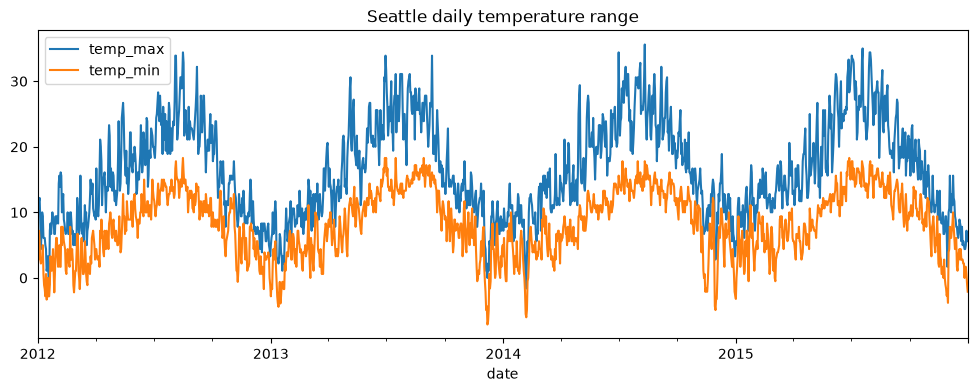

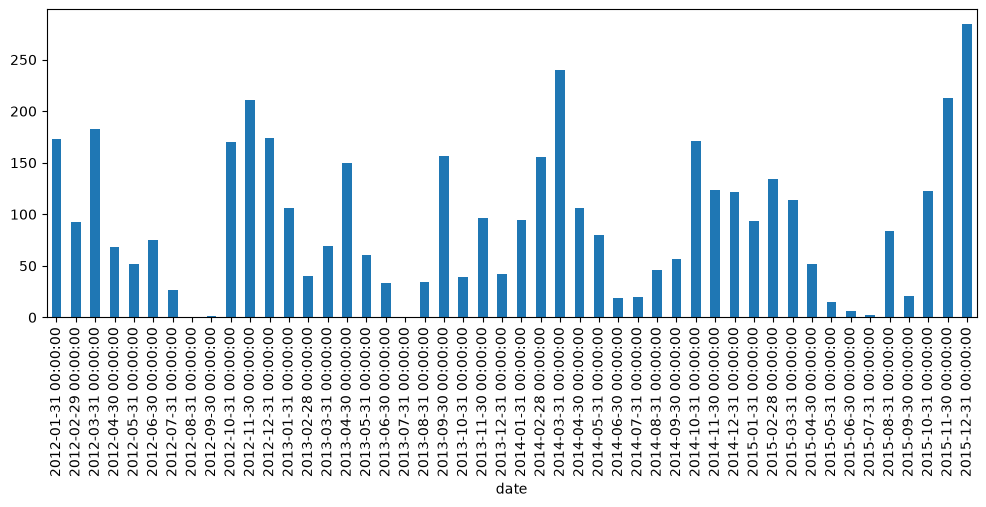

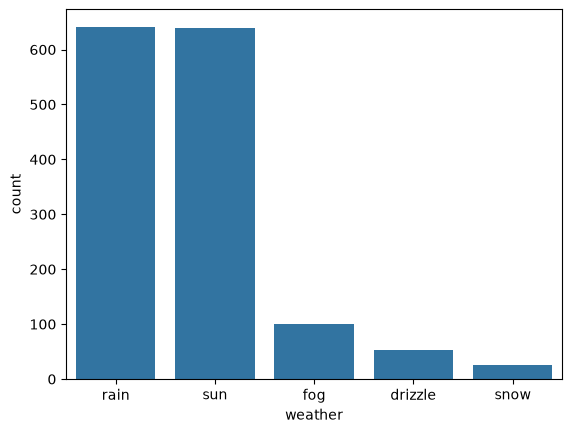

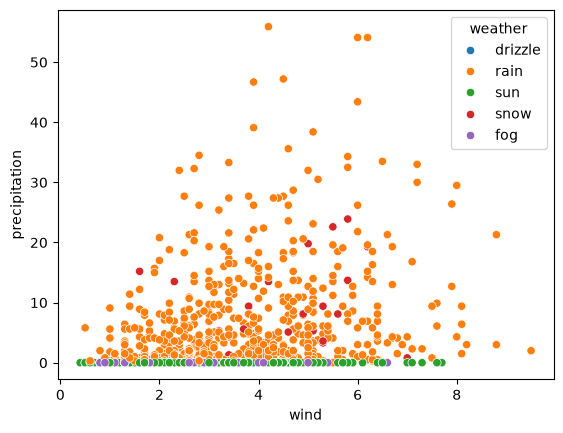

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

def profile(df, name):
    """Standard first-pass inspection of any tabular dataset."""
    print(f"===== {name} =====")
    print("Shape:", df.shape)
    print("\nDtypes:\n", df.dtypes)
    print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
    print("\nDuplicated rows:", df.duplicated().sum())
    print("\nNumeric summary:\n", df.describe())
    return df.select_dtypes(include=np.number).columns.tolist()

def clean(df):
    df = df.drop_duplicates()
    for c in df.select_dtypes(include=np.number).columns:
        df[c] = df[c].fillna(df[c].median())
    for c in df.select_dtypes(include='object').columns:
        if df[c].isnull().any():
            df[c] = df[c].fillna(df[c].mode()[0])
    return df

paths = {
    'titanic':   'data/archive/train_and_test2.csv',
    'weather':   'data/archive (1)/seattle-weather.csv',
    'iris':      'data/archive (2)/Iris.csv',
    'wine':      'data/archive (3)/winequality-red.csv',
    'heart':     'data/archive (4)/heart.csv',
    'titles':    'data/archive (5)/titles.csv',
    'cars':      'data/archive (6)/Sport car price.csv',
    'students':  'data/archive (7)/StudentPerformanceFactors.csv',
    'villagers': 'data/animalCrossing/villagers.csv',
    'fifa':      'data/fifa/fifa2026_player_performance_clean.csv',
}

data = {name: pd.read_csv(p) for name, p in paths.items()}

for name, df in data.items():
    print(f"{name:10} {df.shape}  ->  {list(df.columns)[:6]}")

w = data['weather'].copy()
num_cols = profile(w, 'Seattle Weather')

w['date'] = pd.to_datetime(w['date'])
w = w.set_index('date').sort_index()
print(w.index.min(), "to", w.index.max())
print("Missing days:", pd.date_range(w.index.min(), w.index.max()).difference(w.index))

w[['temp_max','temp_min']].plot(figsize=(12,4), title='Seattle daily temperature range')
plt.show()

w['precipitation'].resample('ME').sum().plot(kind='bar', figsize=(12,4))
plt.show()

sns.countplot(data=w, x='weather', order=w['weather'].value_counts().index)
plt.show()

sns.scatterplot(data=w, x='wind', y='precipitation', hue='weather')
plt.show()

===== Iris =====
Shape: (150, 6)

Dtypes:
 Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

Missing values:
 Series([], dtype: int64)

Duplicated rows: 0

Numeric summary:
                Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000
Species
Iris-setosa        

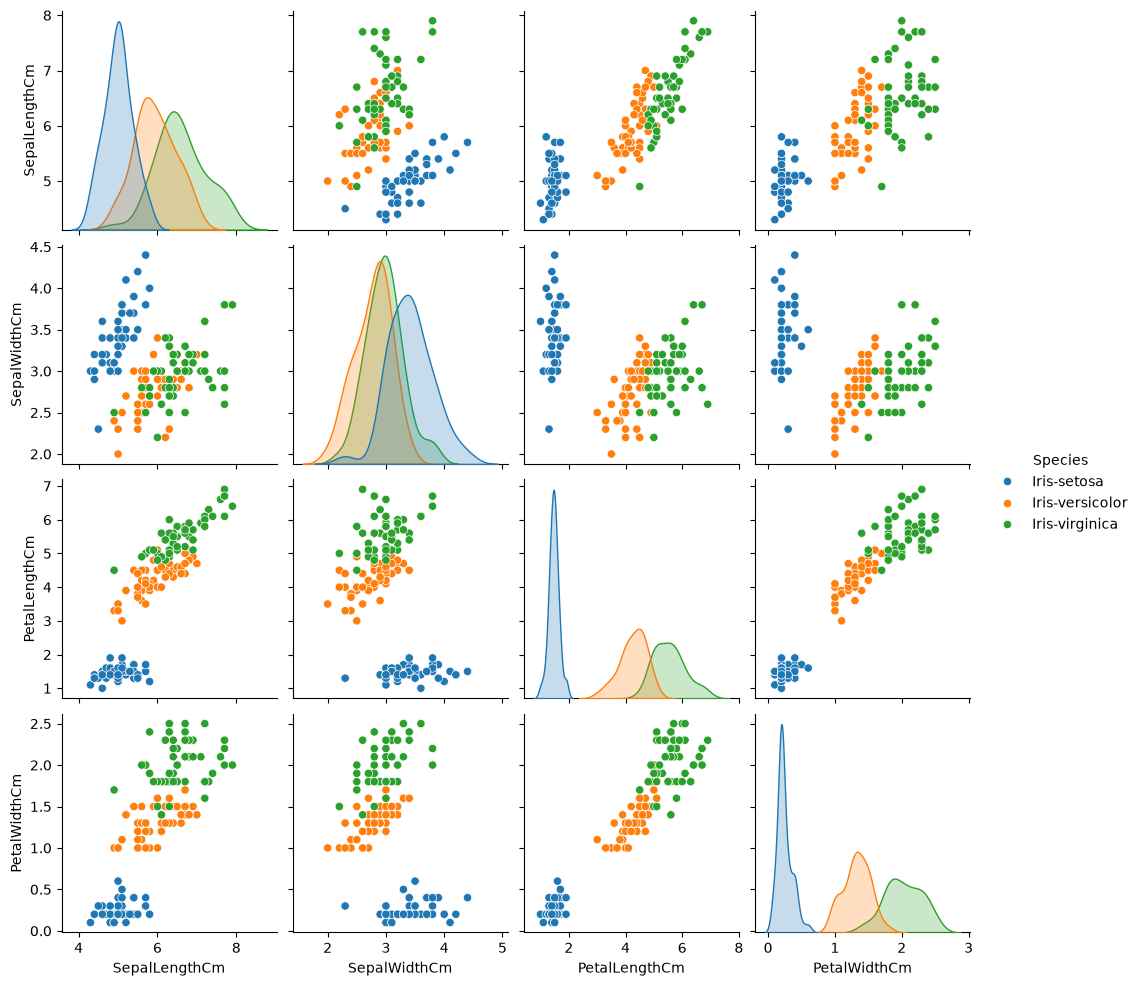

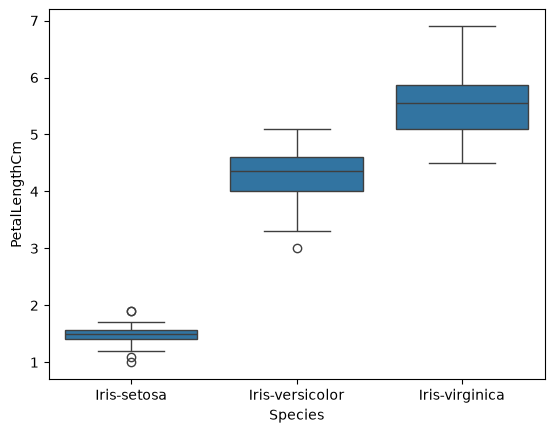

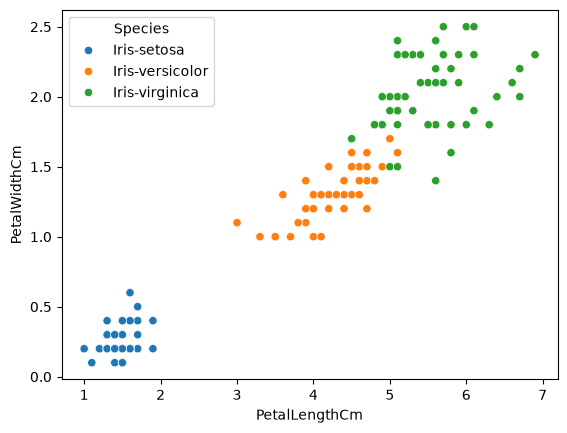

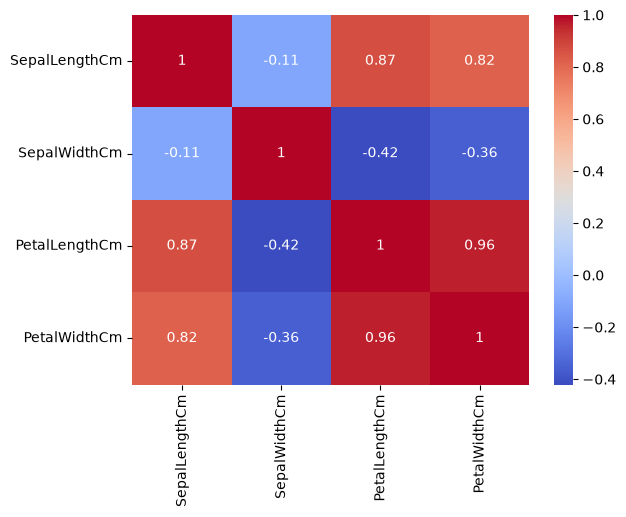

In [35]:
iris = data['iris'].copy()
num_cols = profile(iris, 'Iris')
print(iris['Species'].value_counts())

iris = iris.drop(columns=['Id'])

sns.pairplot(iris, hue='Species')
plt.show()

sns.boxplot(data=iris, x='Species', y='PetalLengthCm')
plt.show()

sns.scatterplot(data=iris, x='PetalLengthCm', y='PetalWidthCm', hue='Species')
plt.show()

sns.heatmap(iris.drop(columns=['Species']).corr(), annot=True, cmap='coolwarm')
plt.show()

===== Wine Quality =====
Shape: (1599, 12)

Dtypes:
 fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing values:
 Series([], dtype: int64)

Duplicated rows: 240

Numeric summary:
        fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000 

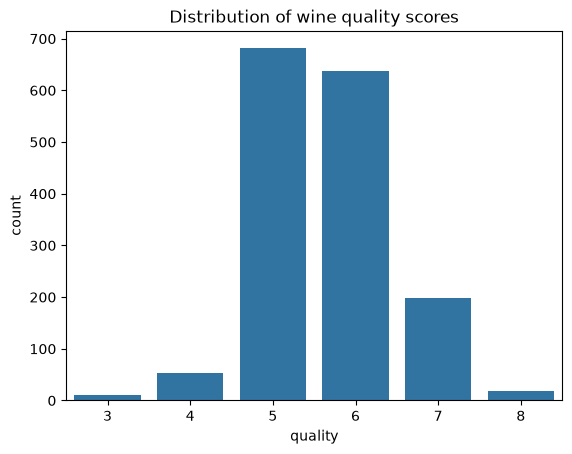

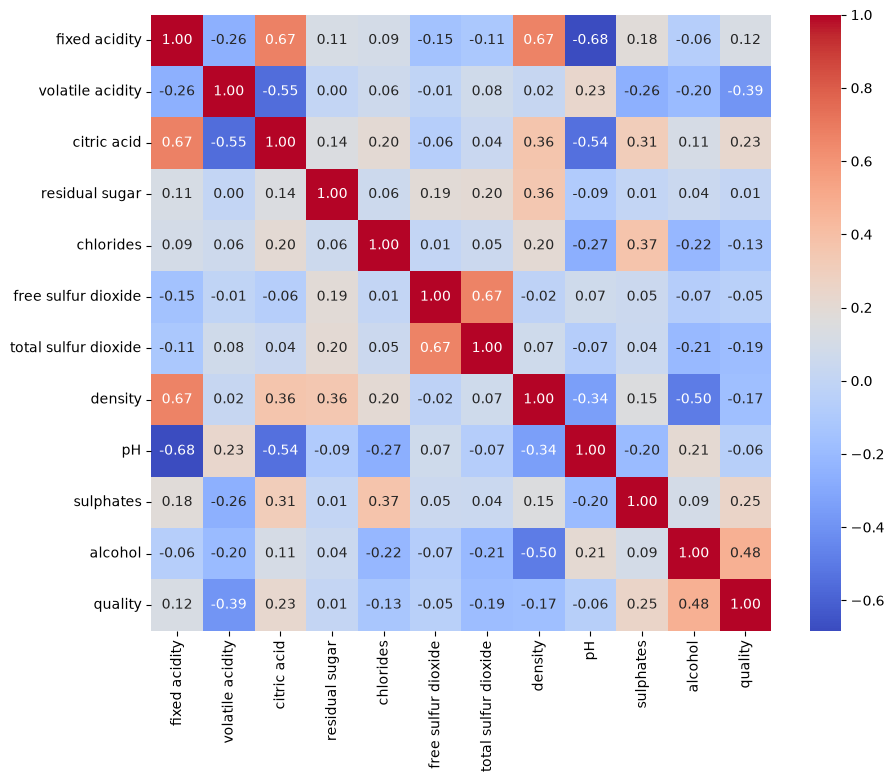

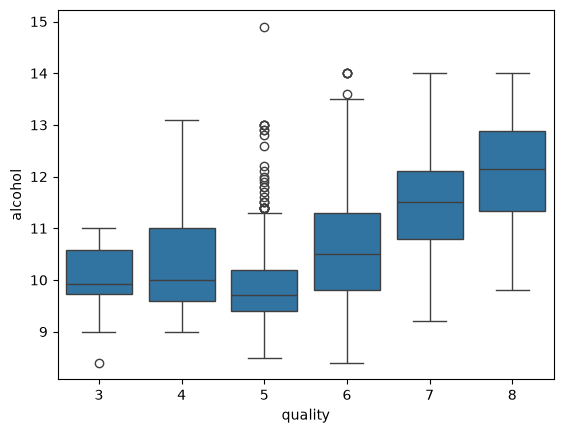

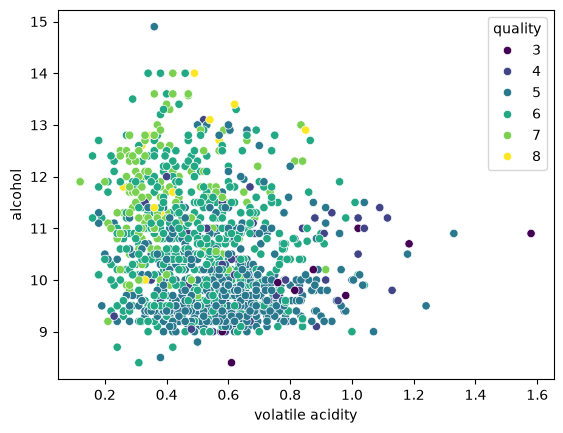

In [36]:
wine = data['wine'].copy()
num_cols = profile(wine, 'Wine Quality')
print(wine['quality'].value_counts().sort_index())
print("Duplicated rows:", wine.duplicated().sum())

sns.countplot(data=wine, x='quality')
plt.title('Distribution of wine quality scores'); plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(wine.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

sns.boxplot(data=wine, x='quality', y='alcohol')
plt.show()

sns.scatterplot(data=wine, x='volatile acidity', y='alcohol', hue='quality', palette='viridis')
plt.show()

===== Heart Disease =====
Shape: (1025, 14)

Dtypes:
 age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Missing values:
 Series([], dtype: int64)

Duplicated rows: 723

Numeric summary:
                age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000

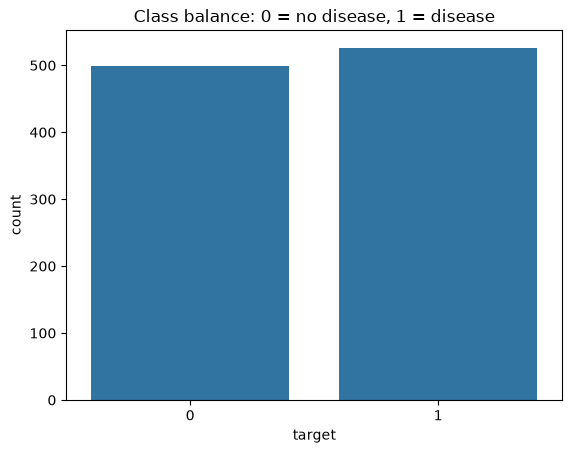

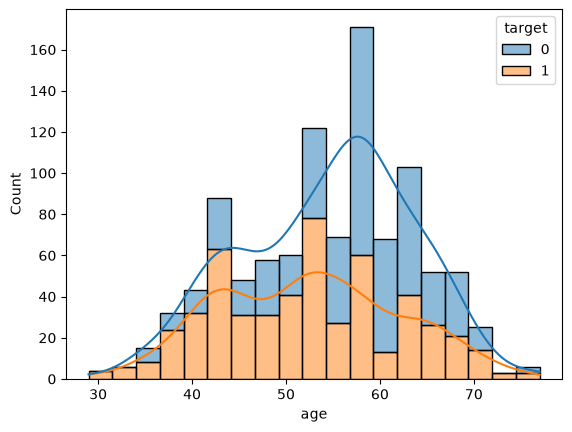

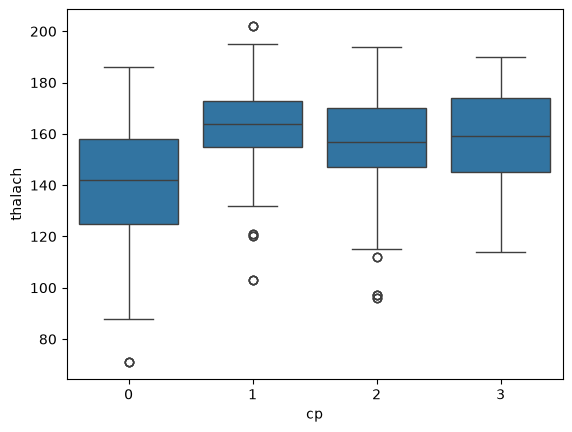

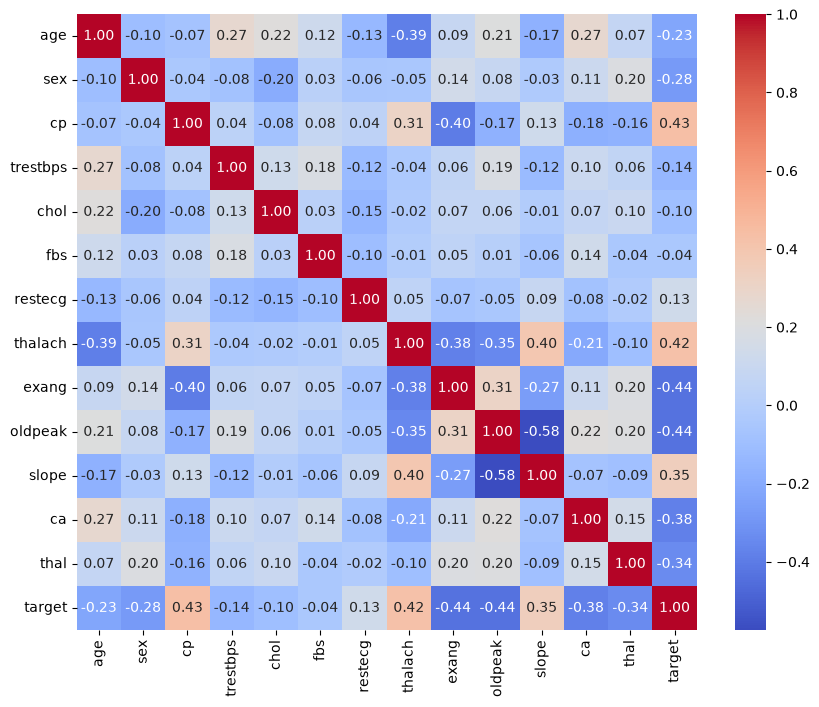

In [37]:
heart = data['heart'].copy()
num_cols = profile(heart, 'Heart Disease')
print(heart['target'].value_counts())
print("Duplicated rows:", heart.duplicated().sum())
for c in ['ca', 'thal', 'sex', 'cp']:
    print(c, sorted(heart[c].unique()))

sns.countplot(data=heart, x='target')
plt.title('Class balance: 0 = no disease, 1 = disease'); plt.show()

sns.histplot(data=heart, x='age', hue='target', kde=True, multiple='stack')
plt.show()

sns.boxplot(data=heart, x='cp', y='thalach')
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(heart.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

===== Sport Car Prices =====
Shape: (1007, 8)

Dtypes:
 Car Make                   object
Car Model                  object
Year                        int64
Engine Size (L)            object
Horsepower                 object
Torque (lb-ft)             object
0-60 MPH Time (seconds)    object
Price (in USD)             object
dtype: object

Missing values:
 Engine Size (L)    10
Torque (lb-ft)      3
dtype: int64

Duplicated rows: 288

Numeric summary:
               Year
count  1007.000000
mean   2021.201589
std       2.019802
min    1965.000000
25%    2021.000000
50%    2021.000000
75%    2022.000000
max    2023.000000
Car Make                   object
Car Model                  object
Year                        int64
Engine Size (L)            object
Horsepower                 object
Torque (lb-ft)             object
0-60 MPH Time (seconds)    object
Price (in USD)             object
dtype: object
      Car Make Car Model  Year Engine Size (L) Horsepower Torque (lb-ft)  \
0      Po

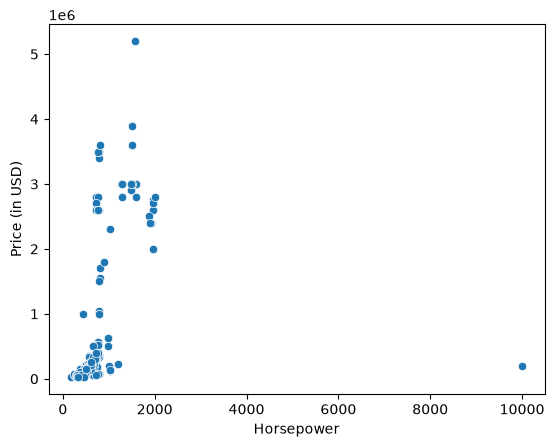

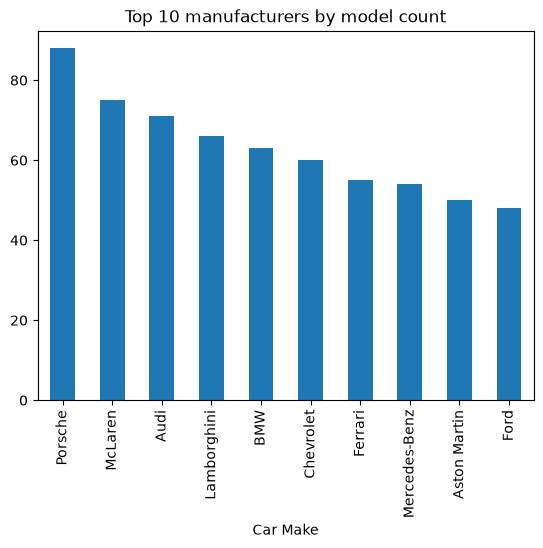

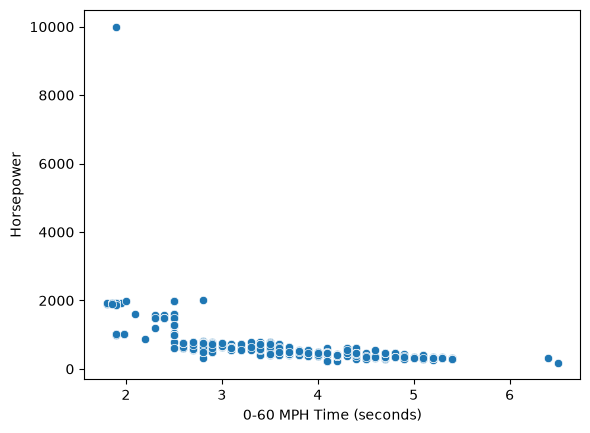

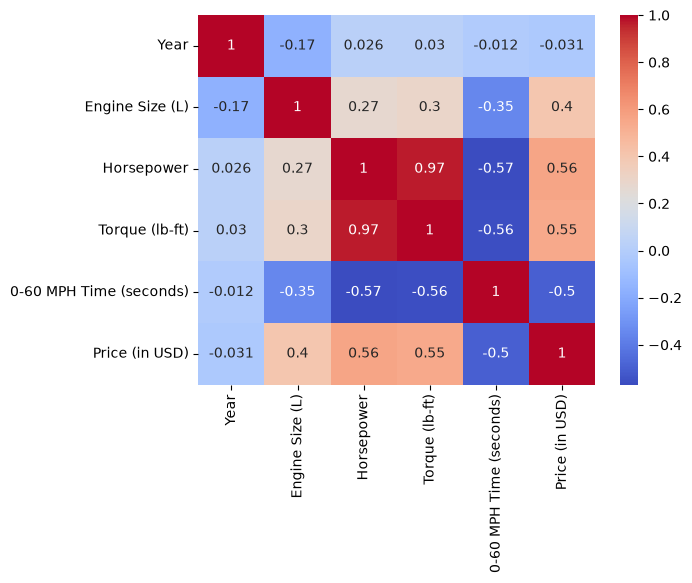

In [38]:
cars = data['cars'].copy()
num_cols = profile(cars, 'Sport Car Prices')
print(cars.dtypes)
print(cars.head())

for c in ['Horsepower', 'Torque (lb-ft)', 'Price (in USD)', 'Engine Size (L)', '0-60 MPH Time (seconds)']:
    cars[c] = pd.to_numeric(cars[c].astype(str).str.replace(',', ''), errors='coerce')

print(cars.isnull().sum())

sns.scatterplot(data=cars, x='Horsepower', y='Price (in USD)')
plt.show()

cars['Car Make'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 manufacturers by model count'); plt.show()

sns.scatterplot(data=cars, x='0-60 MPH Time (seconds)', y='Horsepower')
plt.show()

sns.heatmap(cars.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show()

===== Student Performance Factors =====
Shape: (6607, 20)

Dtypes:
 Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

Missing values:
 Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Duplicated rows: 0

Numeric summary:
        Hours_St

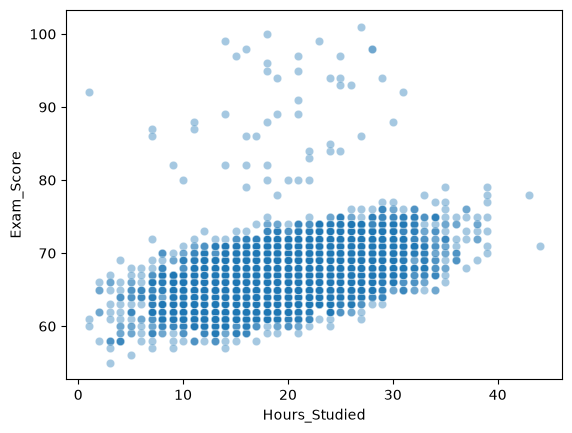

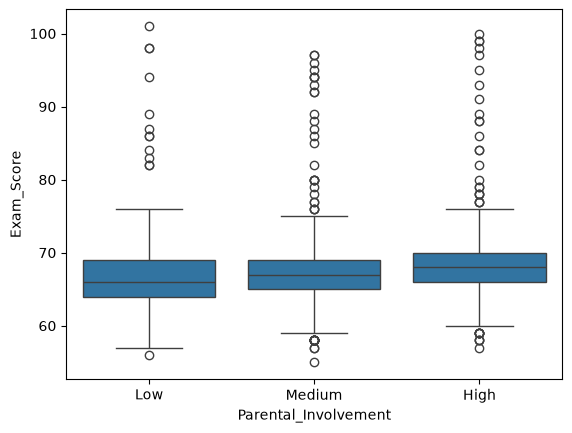

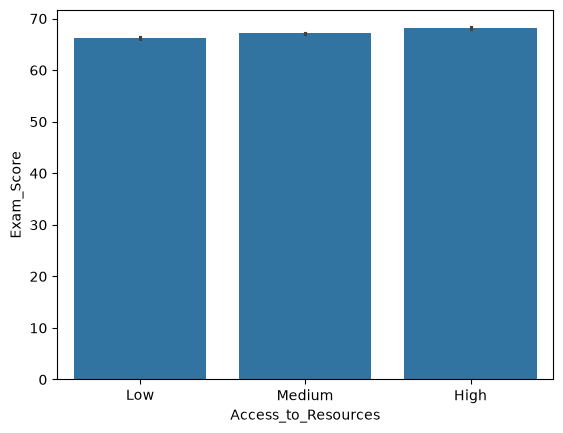

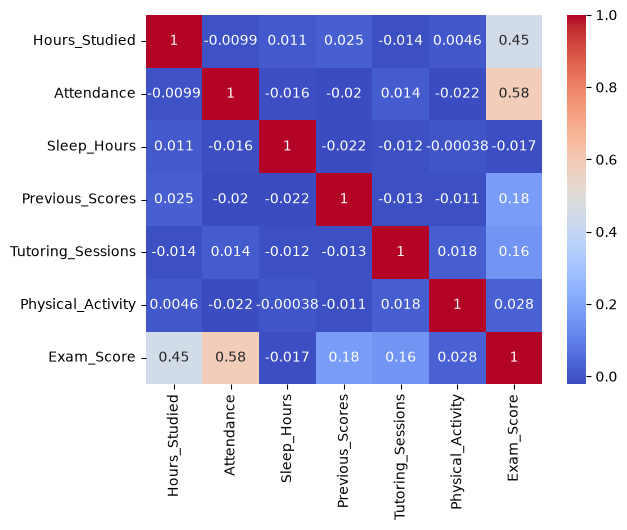

In [39]:
students = data['students'].copy()
num_cols = profile(students, 'Student Performance Factors')
print(students.dtypes)
print(students.isnull().sum()[students.isnull().sum() > 0])

sns.scatterplot(data=students, x='Hours_Studied', y='Exam_Score', alpha=0.4)
plt.show()

sns.boxplot(data=students, x='Parental_Involvement', y='Exam_Score',
            order=['Low','Medium','High'])
plt.show()

sns.barplot(data=students, x='Access_to_Resources', y='Exam_Score',
            order=['Low','Medium','High'])
plt.show()

sns.heatmap(students.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show()

['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived']
Passengerid    1309
Age              98
Fare            281
Sex               2
sibsp             7
zero              1
zero.1            1
zero.2            1
zero.3            1
zero.4            1
zero.5            1
zero.6            1
Parch             8
zero.7            1
zero.8            1
zero.9            1
zero.10           1
zero.11           1
zero.12           1
zero.13           1
zero.14           1
Pclass            3
zero.15           1
zero.16           1
Embarked          3
zero.17           1
zero.18           1
2urvived          2
dtype: int64
Embarked    2
dtype: int64
Dropping constant columns: ['zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'zero.7', 'zero.8

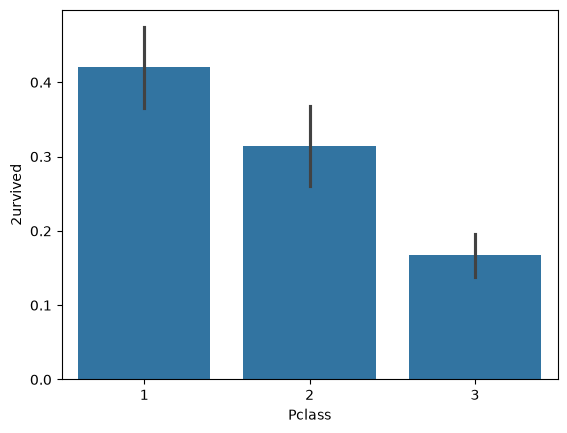

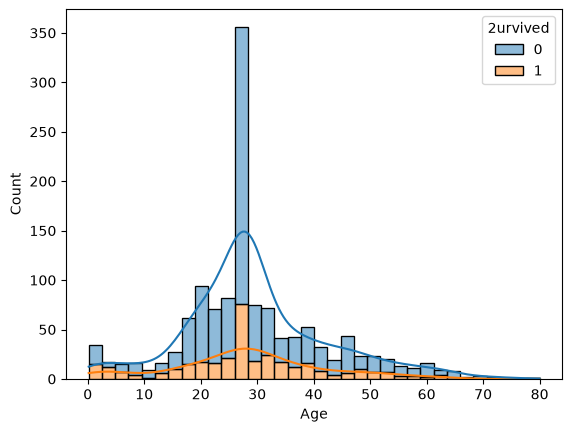

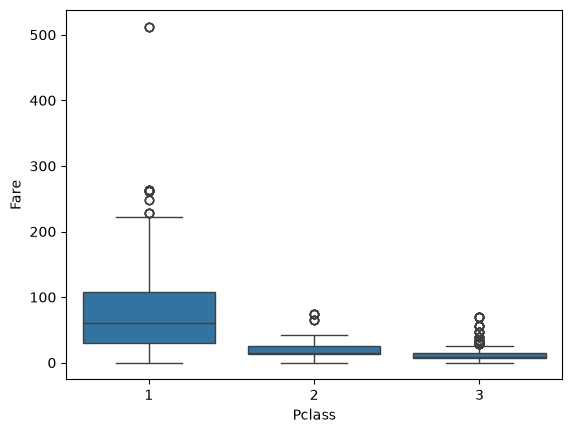

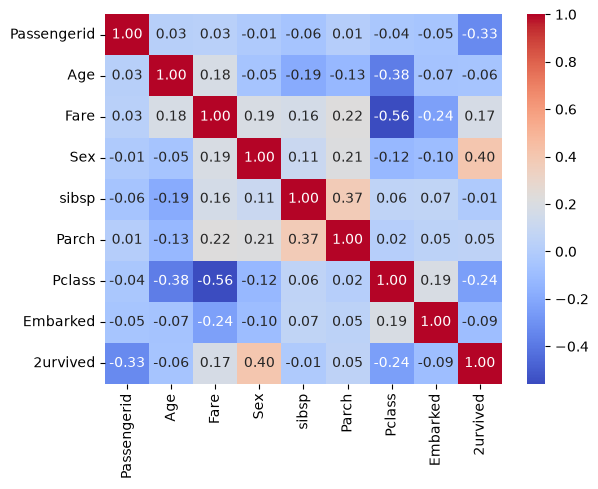

In [40]:
titanic = data['titanic'].copy()
print(titanic.columns.tolist())
print(titanic.nunique())
print(titanic.isnull().sum()[titanic.isnull().sum() > 0])

constant_cols = [c for c in titanic.columns if titanic[c].nunique() <= 1]
print("Dropping constant columns:", constant_cols)
titanic = titanic.drop(columns=constant_cols)
print(titanic.columns.tolist())

titanic['Age'] = titanic.groupby('Pclass')['Age'].transform(lambda s: s.fillna(s.median()))

sns.barplot(data=titanic, x='Pclass', y='2urvived')
plt.show()

sns.histplot(data=titanic, x='Age', hue='2urvived', kde=True, multiple='stack')
plt.show()

sns.boxplot(data=titanic, x='Pclass', y='Fare')
plt.show()

sns.heatmap(titanic.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

===== Streaming Titles =====
Shape: (5850, 15)

Dtypes:
 id                       object
title                    object
type                     object
description              object
release_year              int64
age_certification        object
runtime                   int64
genres                   object
production_countries     object
seasons                 float64
imdb_id                  object
imdb_score              float64
imdb_votes              float64
tmdb_popularity         float64
tmdb_score              float64
dtype: object

Missing values:
 title                   1
description            18
age_certification    2619
seasons              3744
imdb_id               403
imdb_score            482
imdb_votes            498
tmdb_popularity        91
tmdb_score            311
dtype: int64

Duplicated rows: 0

Numeric summary:
        release_year      runtime      seasons   imdb_score    imdb_votes  \
count   5850.000000  5850.000000  2106.000000  5368.000000  5.352000e

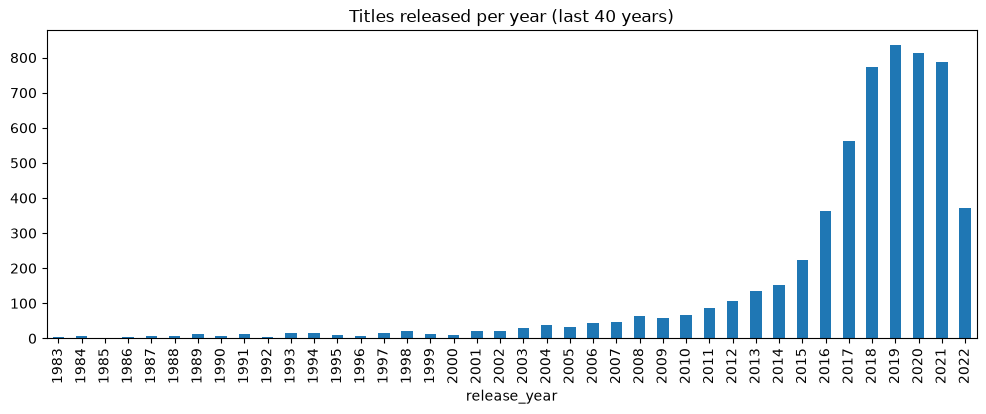

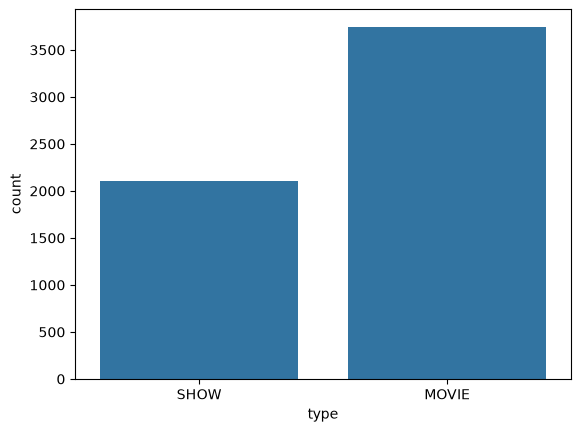

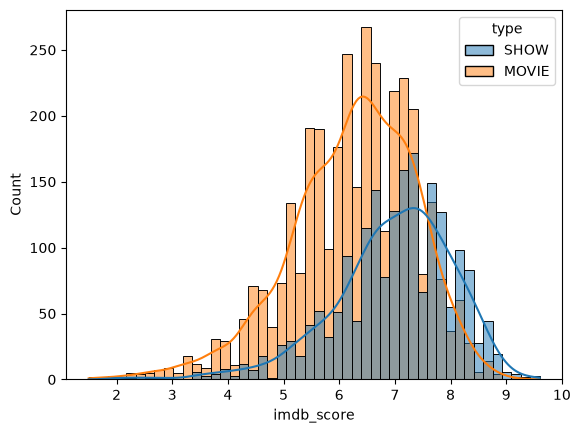

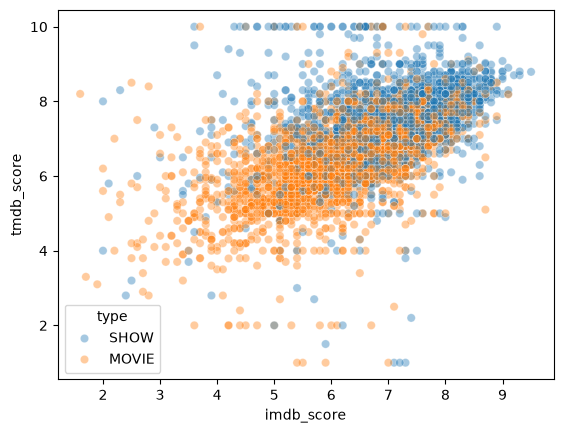

In [41]:
titles = data['titles'].copy()
num_cols = profile(titles, 'Streaming Titles')
print(titles['type'].value_counts())
print(titles.isnull().sum().sort_values(ascending=False).head(10))

titles['release_year'].value_counts().sort_index().tail(40).plot(kind='bar', figsize=(12,4))
plt.title('Titles released per year (last 40 years)'); plt.show()

sns.countplot(data=titles, x='type')
plt.show()

sns.histplot(data=titles, x='imdb_score', hue='type', kde=True)
plt.show()

sns.scatterplot(data=titles, x='imdb_score', y='tmdb_score', hue='type', alpha=0.4)
plt.show()

In [42]:
v = data['villagers'].copy()
profile(v, 'Animal Crossing Villagers')

v['Species'].value_counts().plot(kind='bar', figsize=(12,4))
plt.title('Villagers per species'); plt.show()

sns.countplot(data=v, x='Personality', order=v['Personality'].value_counts().index)
plt.show()

pd.crosstab(v['Personality'], v['Gender']).plot(kind='bar', stacked=True)
plt.show()

sns.countplot(data=v, x='Hobby')
plt.show()

KeyError: 'villagers'

===== FIFA 2026 Player Performance =====
Shape: (13397, 21)

Dtypes:
 player_name             object
nationality             object
club                    object
position                object
age                      int64
market_value_eur_m     float64
season                  object
competition             object
match_id                 int64
minutes_played           int64
goals                    int64
assists                  int64
shots_on_target          int64
pass_accuracy_pct      float64
tackles                  int64
distance_covered_km    float64
match_rating           float64
yellow_card               bool
red_card                  bool
fouls_committed          int64
injured_flag              bool
dtype: object

Missing values:
 market_value_eur_m     270
pass_accuracy_pct      807
distance_covered_km    679
dtype: int64

Duplicated rows: 0

Numeric summary:
                 age  market_value_eur_m       match_id  minutes_played  \
count  13397.000000        13127.000000 

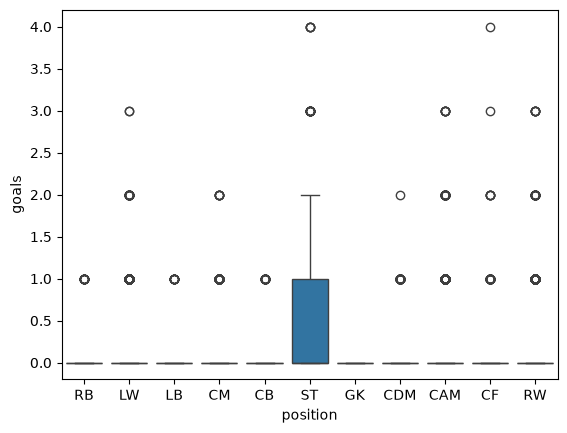

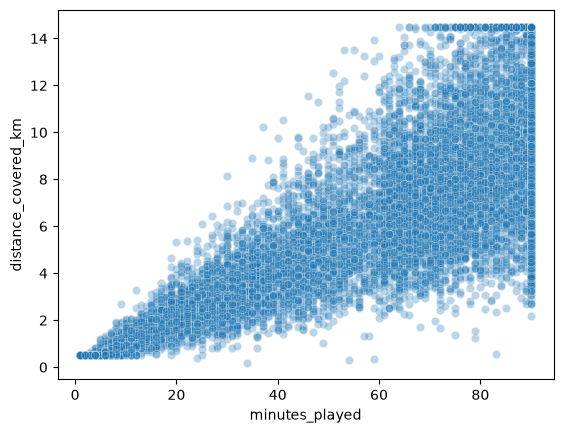

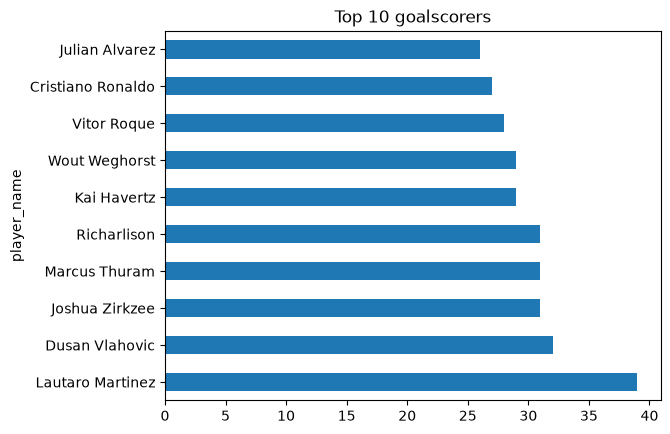

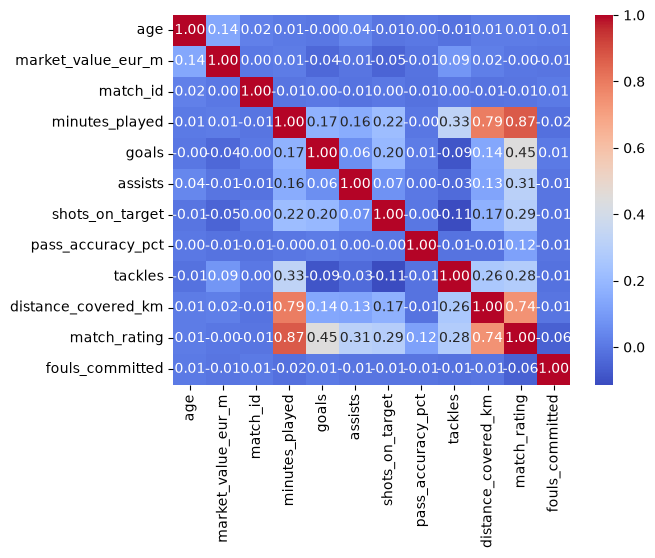

In [ ]:
f = data['fifa'].copy()
profile(f, 'FIFA 2026 Player Performance')
print(f['position'].value_counts())
print(f['season'].value_counts())

sns.boxplot(data=f, x='position', y='goals')
plt.show()

sns.scatterplot(data=f, x='minutes_played', y='distance_covered_km', alpha=0.3)
plt.show()

top = f.groupby('player_name')['goals'].sum().nlargest(10)
top.plot(kind='barh'); plt.title('Top 10 goalscorers'); plt.show()

sns.heatmap(f.select_dtypes(include=np.number).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()